In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("datasets/train.csv")
M, N = df.shape
df.head(100)

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,fit,9.00,87.8,20.85,2714.0,12154.0,54.5,1.85,balanced,low,good,active,no,male
96,96,unhealthy,5.34,69.2,24.66,2843.0,NaN,31.7,1.75,non-veg,high,average,active,yes,female
97,97,at-risk,7.78,67.8,24.16,1827.0,8097.0,47.5,NaN,balanced,high,poor,moderate,no,female
98,98,at-risk,8.42,64.0,24.14,2440.0,14273.0,63.6,1.43,non-veg,high,good,active,no,other


### Анализ количества и природы пропусков

In [3]:
# сначала найдём все потенциально невалидные даанные
borders = {"sleep_duration": [0.0, 24.0], "heart_rate": [0.0, 220.0], "bmi": [0.0, 100],
           "calorie_expenditure": [0.0, np.inf], "step_count": [0.0, np.inf], 
           "exercise_duration": [0.0, 1440.0], "water_intake": [0.0, np.inf],
           "diet_type": ("veg", "non-veg", "balanced"), "stress_level": ("low", "high", "medium"),
           "sleep_quality": ('average', 'poor', 'good'), "physical_activity_level": ('sedentary', 'moderate', 'active'),
           "smoking_alcohol": ('yes', 'occasional', 'no'), "gender": ('female', 'other', 'male')}

for col_name in df.columns:
    if col_name not in borders:
        continue
    else:
        try:
            if type(borders[col_name]) is tuple:
                mask = ~(df[col_name].isin(borders[col_name]) | df[col_name].isna())
            elif type(borders[col_name]) is list:
                mask = ~(((df[col_name] >= borders[col_name][0]) & (df[col_name] <= borders[col_name][1])) | df[col_name].isna())
            else:
                raise AttributeError("Нестандартный тип данных из словаря borders")
        except AttributeError as ae:
            print(f"Словарь borders повреждён: {ae}")
        print(f"Столбец {col_name}: {mask.sum()}")
        
            

Столбец sleep_duration: 0
Столбец heart_rate: 0
Столбец bmi: 0
Столбец calorie_expenditure: 0
Столбец step_count: 0
Столбец exercise_duration: 0
Столбец water_intake: 0
Столбец diet_type: 0
Столбец stress_level: 0
Столбец sleep_quality: 0
Столбец physical_activity_level: 0
Столбец smoking_alcohol: 0
Столбец gender: 0


### Вывод
Данные лежат в валидных интервалах

In [4]:
df.isnull().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

In [5]:
missing_per_row = df.isnull().sum(axis=1)
missing_counts = [[num, np.round(num/M, 2)] for num in missing_per_row.value_counts().sort_index()]
print("Количество строк с определенным числом пропусков (кол-во, процент от всего df):")
print(*missing_counts, sep="\n")

Количество строк с определенным числом пропусков (кол-во, процент от всего df):
[349623, np.float64(0.51)]
[248134, np.float64(0.36)]
[77311, np.float64(0.11)]
[13445, np.float64(0.02)]
[1479, np.float64(0.0)]
[87, np.float64(0.0)]
[9, np.float64(0.0)]


In [6]:
# так как общий процент сэмплов с 3+ пропусками <= 0.2, то откинем их
df = df[~(df.isnull().sum(axis=1) >= 3)]

Дальше надо решить проблему обработки категориальных признаков. Воспользуемся One Hot Encoding

In [7]:
# Заменяем NaN на медианные значения
from sklearn.preprocessing import OneHotEncoder

columns_categor = ["diet_type", "stress_level", "sleep_quality", "physical_activity_level", "smoking_alcohol", "gender"]

df_Y = df[["id", "health_condition"]].copy()
df.drop(columns=["id", "health_condition"], inplace=True)

df_numerical = df.drop(columns=columns_categor)
df_numerical = df_numerical.fillna(df_numerical.median())

df_categorical = df[columns_categor].fillna("Missing")
encoder = OneHotEncoder(sparse_output=False)
df_categorical_encoded = encoder.fit_transform(df_categorical)

df_categorical = pd.DataFrame(
    df_categorical_encoded,
    columns=encoder.get_feature_names_out(columns_categor),
    index=df_categorical.index 
)

df = pd.concat([df_Y, df_numerical, df_categorical], axis=1)

print(df.isna().sum())

id                                   0
health_condition                     0
sleep_duration                       0
heart_rate                           0
bmi                                  0
calorie_expenditure                  0
step_count                           0
exercise_duration                    0
water_intake                         0
diet_type_Missing                    0
diet_type_balanced                   0
diet_type_non-veg                    0
diet_type_veg                        0
stress_level_Missing                 0
stress_level_high                    0
stress_level_low                     0
stress_level_medium                  0
sleep_quality_Missing                0
sleep_quality_average                0
sleep_quality_good                   0
sleep_quality_poor                   0
physical_activity_level_Missing      0
physical_activity_level_active       0
physical_activity_level_moderate     0
physical_activity_level_sedentary    0
smoking_alcohol_Missing  

#### Разделим данные

In [8]:
df = df.drop(["id"], axis=1)
df['health_condition'] = df['health_condition'].map({'at-risk': 0, 'unhealthy': 1, 'fit': 2})

#### На 3 выборки: train(70%), validate(20%), test(10%)

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['health_condition'])
y = df['health_condition']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.3333,
    random_state=42,
    stratify=y_temp
)


df_train = pd.concat([X_train, y_train], axis=1)
df_val = pd.concat([X_val, y_val], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

#### Последующая часть валидна только для логистической регресии

Проверяем на какой эпохе будет плато и переобучение

In [10]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import RobustScaler

columns_to_scal = ["sleep_duration", "heart_rate", "bmi", "calorie_expenditure", "step_count", "exercise_duration", "water_intake"] 
scaler = RobustScaler()
df_train[columns_to_scal] = scaler.fit_transform(df_train[columns_to_scal])

df_val_test = pd.concat([df_val, df_test], axis=0)
df_val_test[columns_to_scal] = scaler.transform(df_val_test[columns_to_scal])

X_train = df_train.drop(columns=['health_condition'])
y_train = df_train['health_condition'] 

X_val_test = df_val_test.drop(columns=['health_condition'])
y_val_test = df_val_test['health_condition']

In [ ]:
import os
import logging
from datetime import datetime


RS = 42
log_dir = 'logs_log_reg'
os.makedirs(log_dir, exist_ok=True)

# set_of_params = [[64, 5], [128, 5], [1024, 100], [2048, 200], [4096, 200]]

# for params in set_of_params:
#     log_filename = os.path.join(
#         log_dir, 
#         f'train_{datetime.now().strftime(f"%Y-%m-%d_%H-%M_{params[0]};{params[1]}")}.log'
#     )

#     logging.basicConfig(
#         level=logging.INFO,
#         format='%(asctime)s - %(message)s',
#         handlers=[
#             logging.FileHandler(log_filename)
#         ],
#         force=True 
#     )

#     batch_size = params[0]
#     epochs = params[1]
#     sgd = SGDClassifier(loss='log_loss', eta0=0.005, shuffle=True, random_state=RS,
#                     class_weight=dict(zip(np.unique(y_train), y_train.shape[0] / (3 * np.bincount(y_train)))))


#     loss_history_train = []
#     loss_history_val_test = []
#     balanced_accuracy_train = []
#     balanced_accuracy_val_test = []
#     classes = np.unique(y_train)

#     # Logging start
#     logging.info("="*60)
#     logging.info("TRAINING STARTED")
#     logging.info(f"Epochs: {epochs}, Batch size: {batch_size}")
#     logging.info(f"Train set size: {X_train.shape[0]}")
#     logging.info(f"Validation set size: {X_val_test.shape[0]}")
#     logging.info("="*60)

#     for epoch in range(epochs):
#         epoch_start = datetime.now()
        
#         logging.info(f"\n--- EPOCH {epoch+1}/{epochs} ---")
#         logging.info(f"Starting epoch {epoch+1}")
        
#         for ind in range(0, X_train.shape[0], batch_size):
#             X_batch = X_train[ind:ind+batch_size]
#             y_batch = y_train[ind:ind+batch_size]
#             sgd.partial_fit(X_batch, y_batch, classes=classes)
        
#         y_pred_train_proba = sgd.predict_proba(X_train)
#         y_pred_val_test_proba = sgd.predict_proba(X_val_test)
        
#         current_train_loss = log_loss(y_train, y_pred_train_proba)
#         current_val_test_loss = log_loss(y_val_test, y_pred_val_test_proba)
        
#         loss_history_train.append(current_train_loss)
#         loss_history_val_test.append(current_val_test_loss)
        
#         y_pred_train = sgd.predict(X_train)
#         y_pred_val_test = sgd.predict(X_val_test)
        
#         current_train_balanced_acc = balanced_accuracy_score(y_train, y_pred_train)
#         current_val_test_balanced_acc = balanced_accuracy_score(y_val_test, y_pred_val_test)
        
#         balanced_accuracy_train.append(current_train_balanced_acc)
#         balanced_accuracy_val_test.append(current_val_test_balanced_acc)
        
#         epoch_end = datetime.now()
#         epoch_duration = (epoch_end - epoch_start).total_seconds()
        
#         logging.info(f"Epoch {epoch+1} results:")
#         logging.info(f"  Train Loss:           {current_train_loss:.6f}")
#         logging.info(f"  Val/Test Loss:        {current_val_test_loss:.6f}")
#         logging.info(f"  Train Bal.Accuracy:   {current_train_balanced_acc:.6f}")
#         logging.info(f"  Val/Test Bal.Accuracy:{current_val_test_balanced_acc:.6f}")
#         logging.info(f"  Loss gap:             {current_train_loss - current_val_test_loss:.6f}")
#         logging.info(f"  Accuracy gap:         {current_train_balanced_acc - current_val_test_balanced_acc:.6f}")
#         logging.info(f"  Epoch time:           {epoch_duration:.2f} sec")
        
#         if current_train_loss < current_val_test_loss - 0.1:
#             logging.warning(f"  WARNING: Possible overfitting in epoch {epoch+1}")
#         elif current_train_loss > current_val_test_loss + 0.1:
#             logging.warning(f"  WARNING: Possible underfitting in epoch {epoch+1}")

#     logging.info("\n" + "="*60)
#     logging.info("TRAINING COMPLETED")
#     logging.info("="*60)
#     logging.info(f"\nFINAL RESULTS (epoch {epochs}):")
#     logging.info(f"  Train Loss:           {loss_history_train[-1]:.6f}")
#     logging.info(f"  Val/Test Loss:        {loss_history_val_test[-1]:.6f}")
#     logging.info(f"  Train Bal.Accuracy:   {balanced_accuracy_train[-1]:.6f}")
#     logging.info(f"  Val/Test Bal.Accuracy:{balanced_accuracy_val_test[-1]:.6f}")

#     best_train_loss_epoch = np.argmin(loss_history_train) + 1
#     best_val_loss_epoch = np.argmin(loss_history_val_test) + 1
#     best_train_acc_epoch = np.argmax(balanced_accuracy_train) + 1
#     best_val_acc_epoch = np.argmax(balanced_accuracy_val_test) + 1

#     logging.info(f"\nBEST VALUES:")
#     logging.info(f"  Best Train Loss:     {min(loss_history_train):.6f} (epoch {best_train_loss_epoch})")
#     logging.info(f"  Best Val/Test Loss:  {min(loss_history_val_test):.6f} (epoch {best_val_loss_epoch})")
#     logging.info(f"  Best Train Acc:      {max(balanced_accuracy_train):.6f} (epoch {best_train_acc_epoch})")
#     logging.info(f"  Best Val/Test Acc:   {max(balanced_accuracy_val_test):.6f} (epoch {best_val_acc_epoch})")

#     logging.info(f"\nLog saved to: {log_filename}")
#     logging.info("="*60)

#     plt.figure(figsize=(10, 6))
#     plt.plot(range(1, epochs + 1), loss_history_train, label='Train Loss', marker='o')
#     plt.plot(range(1, epochs + 1), loss_history_val_test, label='Validation/Test Loss', marker='s')
#     plt.xlabel('Epoch')
#     plt.ylabel('Log Loss')
#     plt.title(f'Loss {params[0]}/{params[1]}')
#     plt.legend()
#     plt.grid(True)
#     plt.show()

#     plt.figure(figsize=(10, 6))
#     plt.plot(range(1, epochs + 1), balanced_accuracy_train, label='Train Balanced Accuracy', marker='o')
#     plt.plot(range(1, epochs + 1), balanced_accuracy_val_test, label='Validation/Test Balanced Accuracy', marker='s')
#     plt.xlabel('Epoch')
#     plt.ylabel('Balanced Accuracy')
#     plt.title(f'Balanced Accuracy {params[0]}/{params[1]}')
#     plt.legend()
#     plt.grid(True)
#     plt.show()

### Тренировка на 100 эпохах батчами (до ~512 сэмплов) показала, что после 5-ой эпохи модель выходит на плато либо начинает переобучаться. При более крупных батчах обучения не происходит, лосс начинает расти (уменьшать шаг обучения не пробовал)

#### обучение по батчам показало лучшее качество чем базовый стахостический подход

#### Теперь проводим параметризацию модели с помощью сетки и останавливаем обучение, если модель слишком медленно учится

In [12]:
def create_table(dct: dict):
    log_filename = os.path.join(
        log_dir, 
        f'table_log_{datetime.now().strftime("%Y%m%d_%H%M%S")}.log'
    )

    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(message)s',
        handlers=[
            logging.FileHandler(log_filename),
            logging.StreamHandler()
        ],
        force=True 
    )

    models = [item[0] for item in dct["bal_acc"]]

    for key in dct.keys():
        scores = [-el[1] for el in dct[key]]  # минусуем для сортировки по убыванию
        ranks = np.argsort(np.argsort(scores)) + 1
        for ind in range(len(dct[key])):
            dct[key][ind].append(ranks[ind])

    lookup = {
        key: {item[0]: (item[1], item[2]) for item in items}
        for key, items in dct.items()
    }

    logging.info(f"{'№':<5} {'bal_acc (val/rank)':<22} {'recall (val/rank)':<22} {'precision (val/rank)':<22} {'f1 (val/rank)':<22} {'accuracy (val/rank)':<22}")
    
    for model in models:
        row = f"№{model:<4} "
        for met in ["bal_acc", "recall", "precision", "f1", "accuracy"]:
            val, rank = lookup[met][model]
            row += f"{val:.4f} R:{rank:<10} "
        logging.info(row)

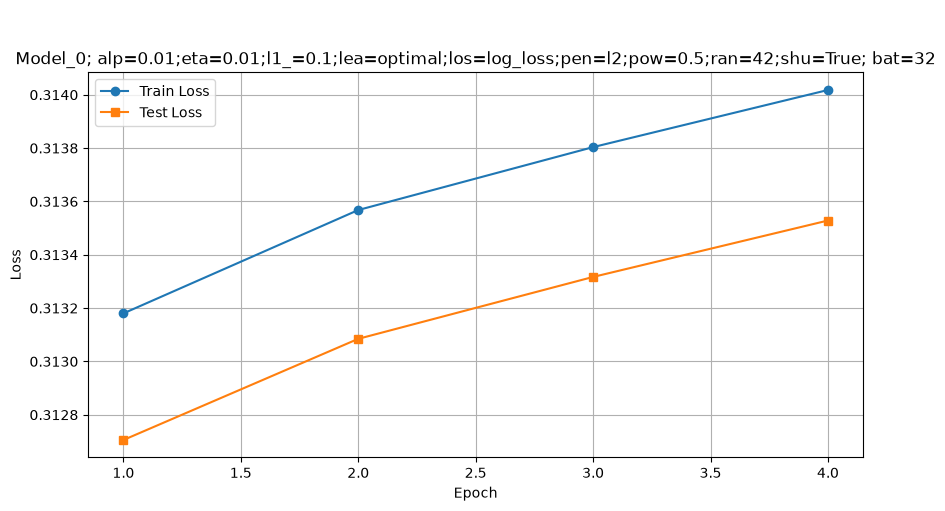

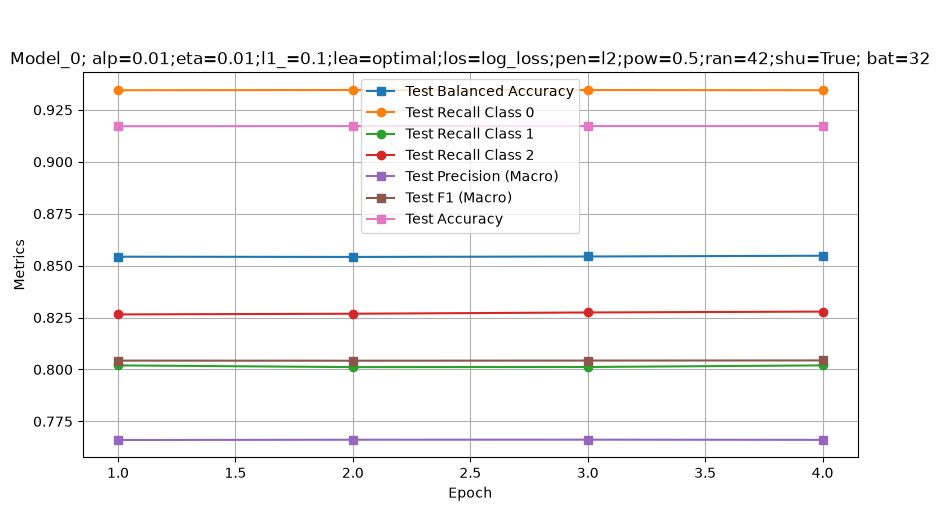

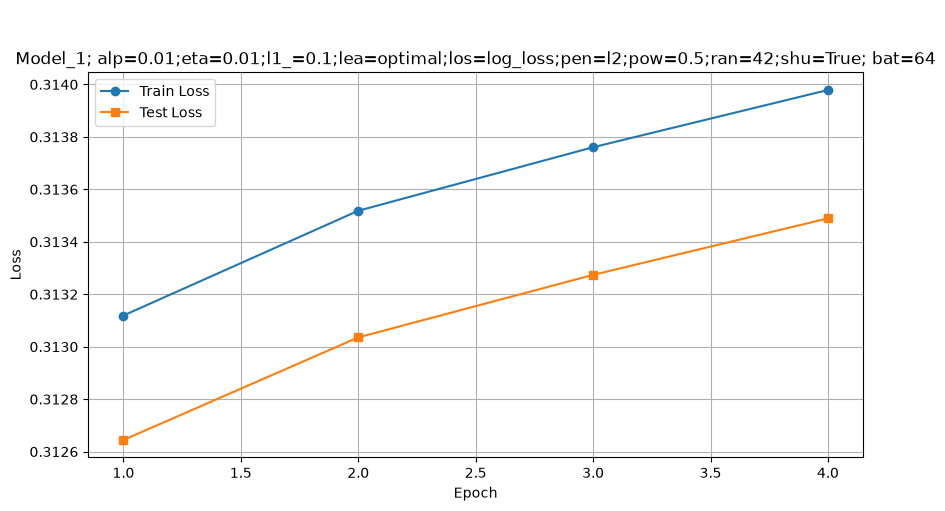

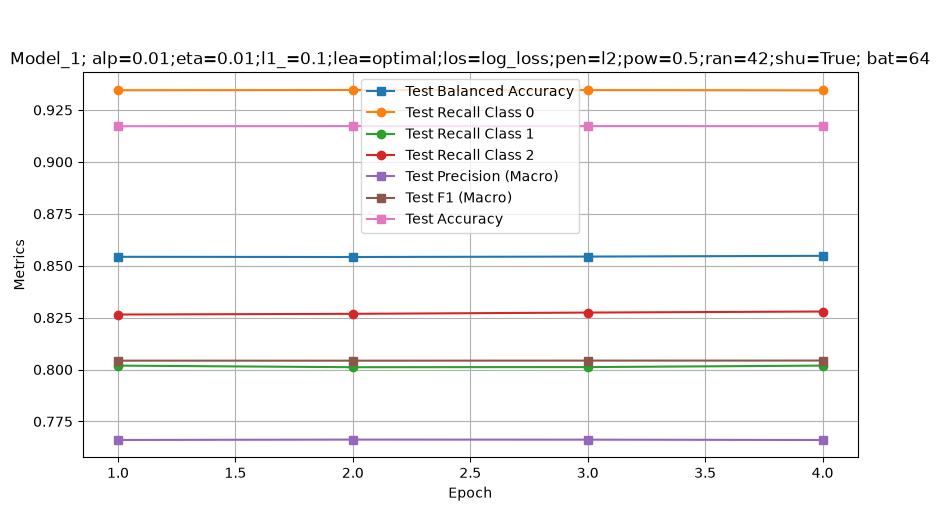

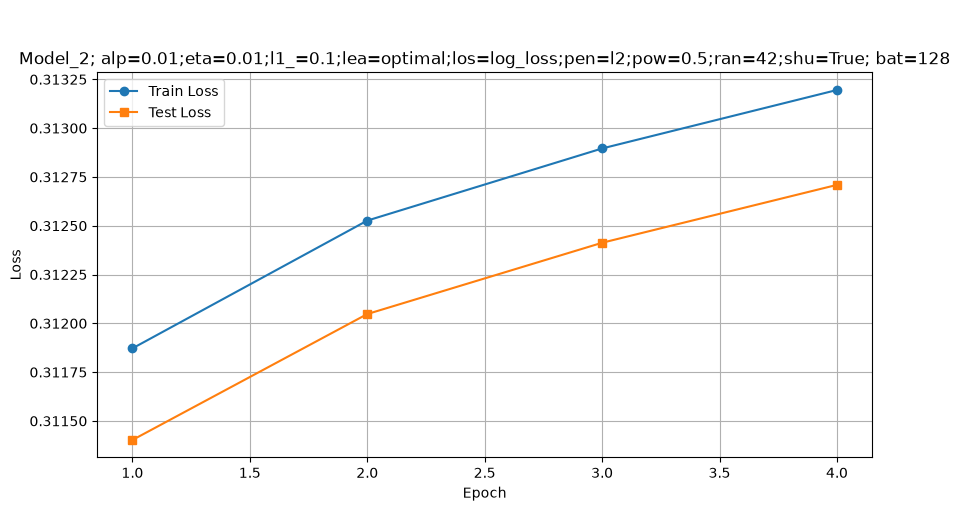

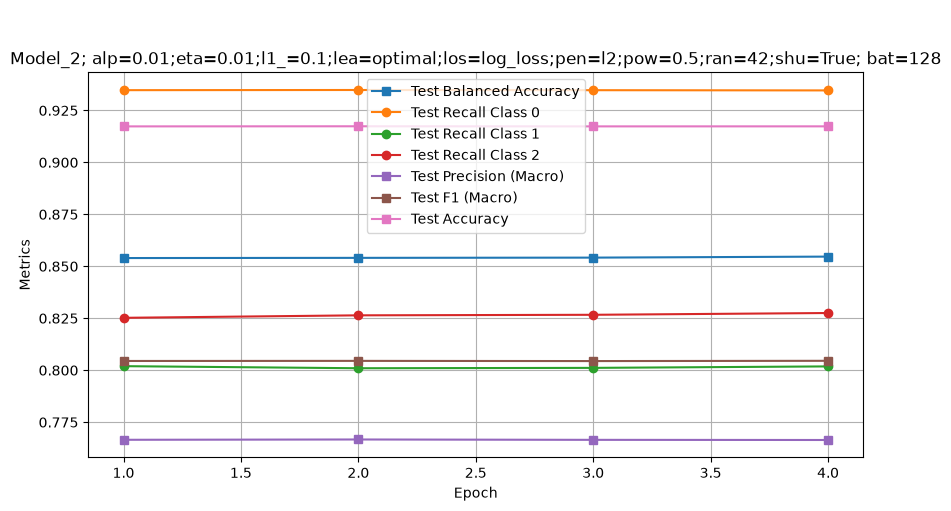

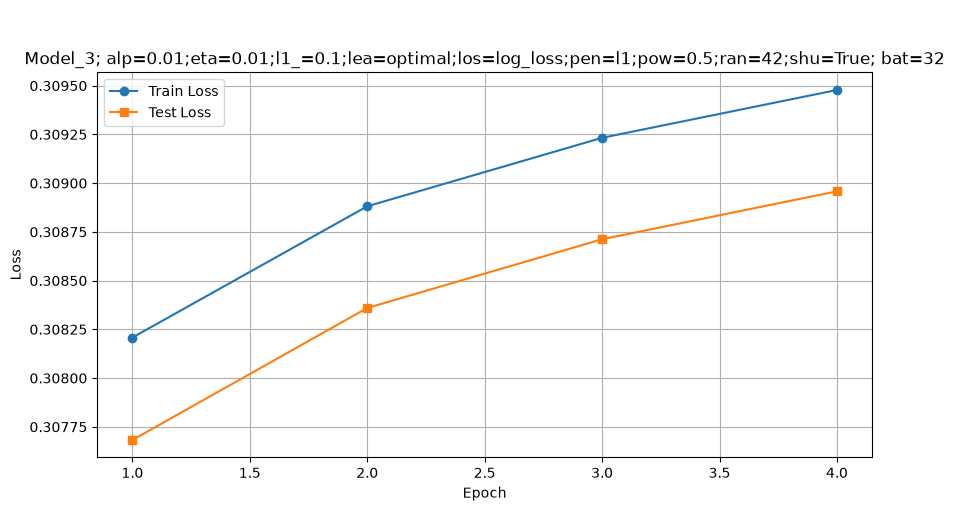

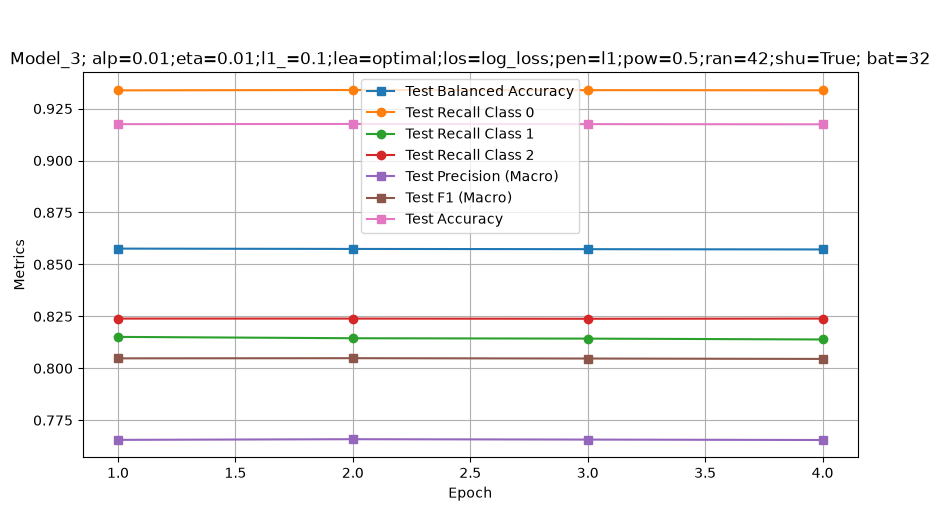

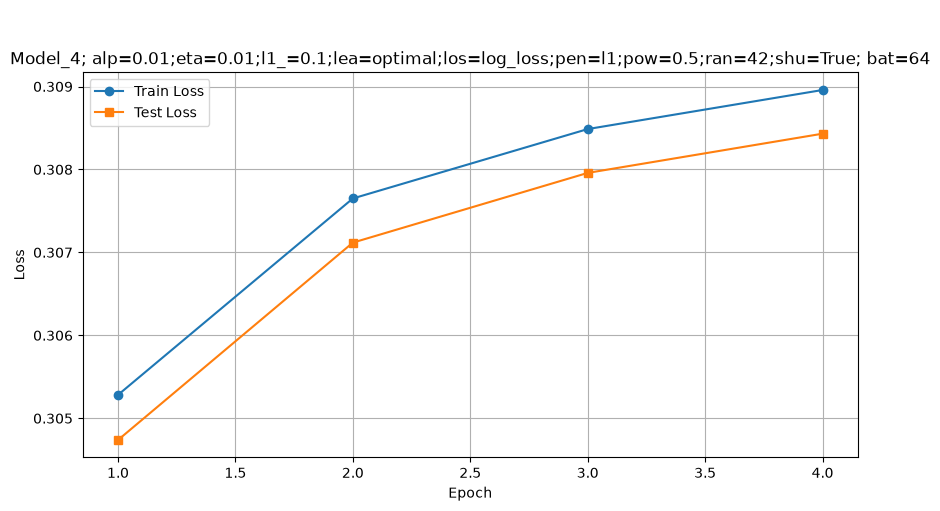

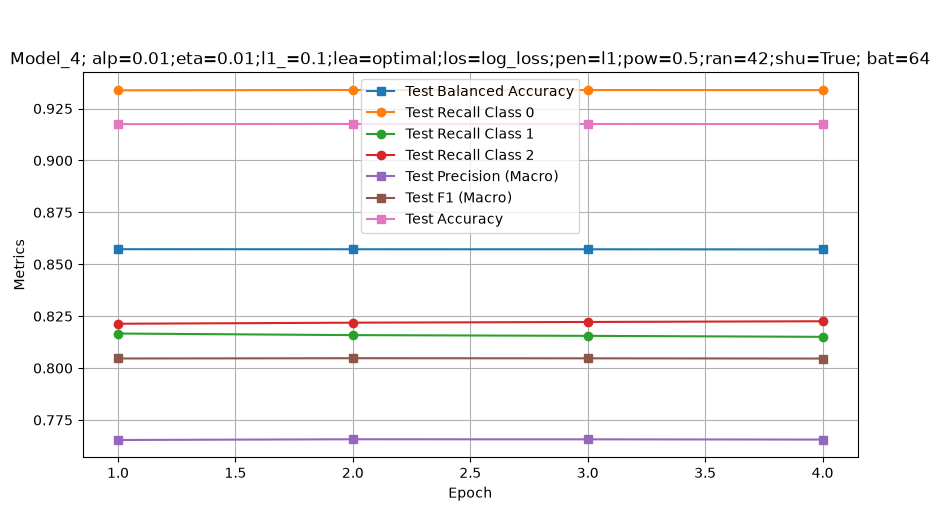

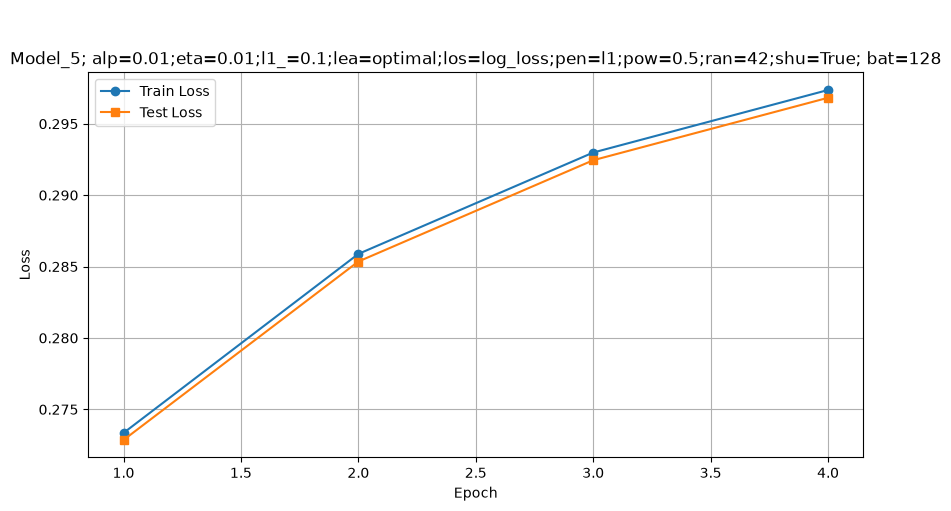

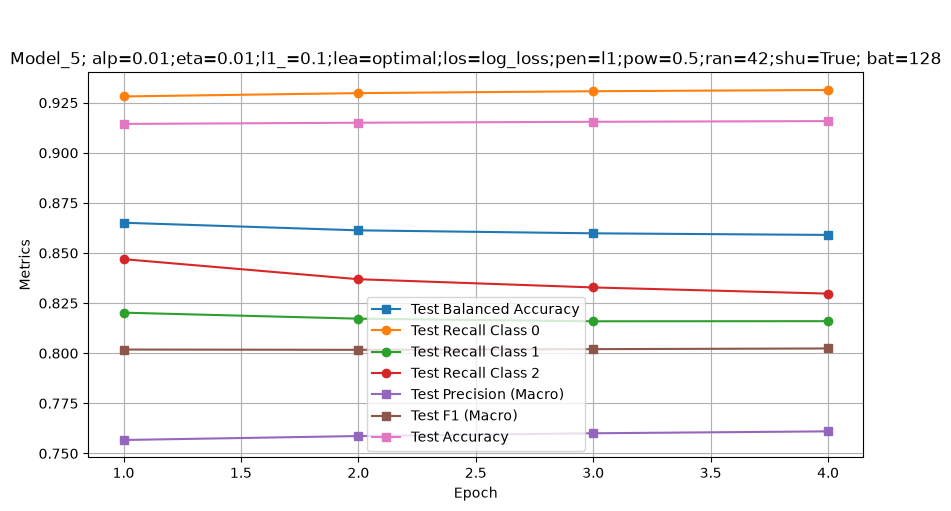

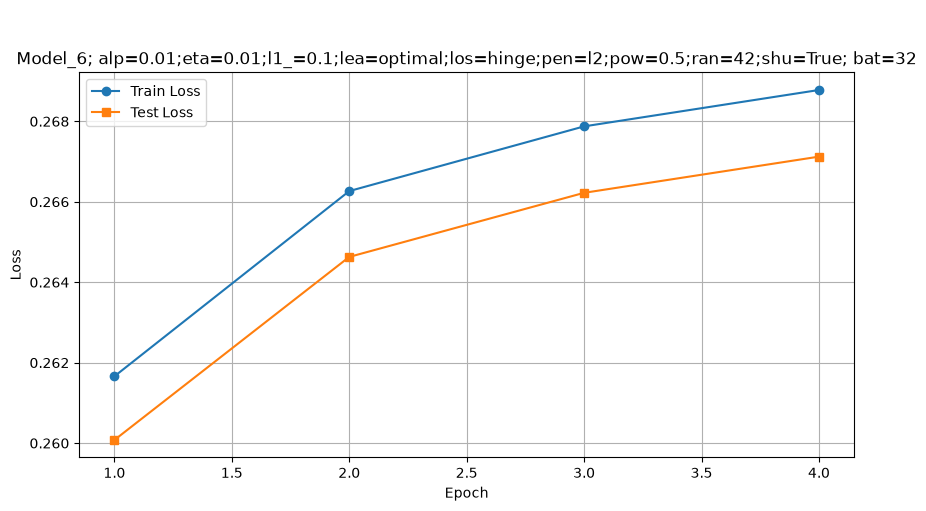

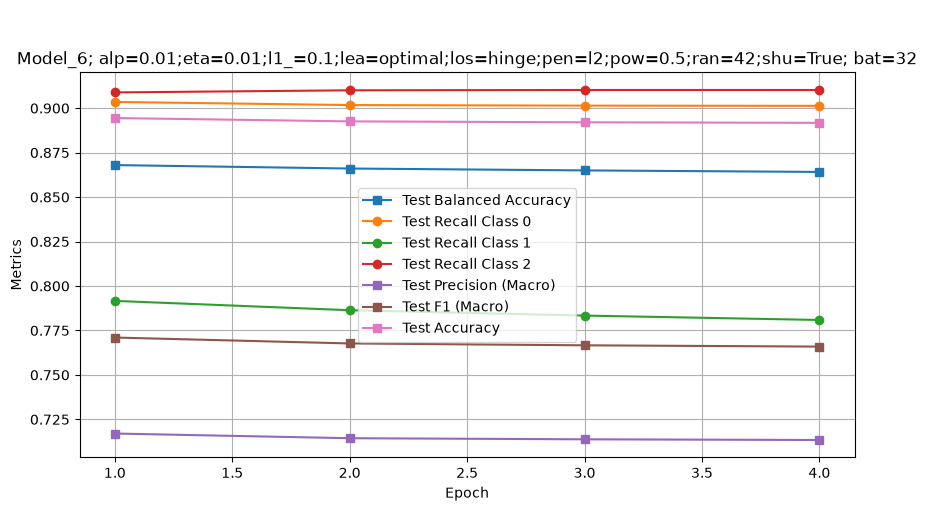

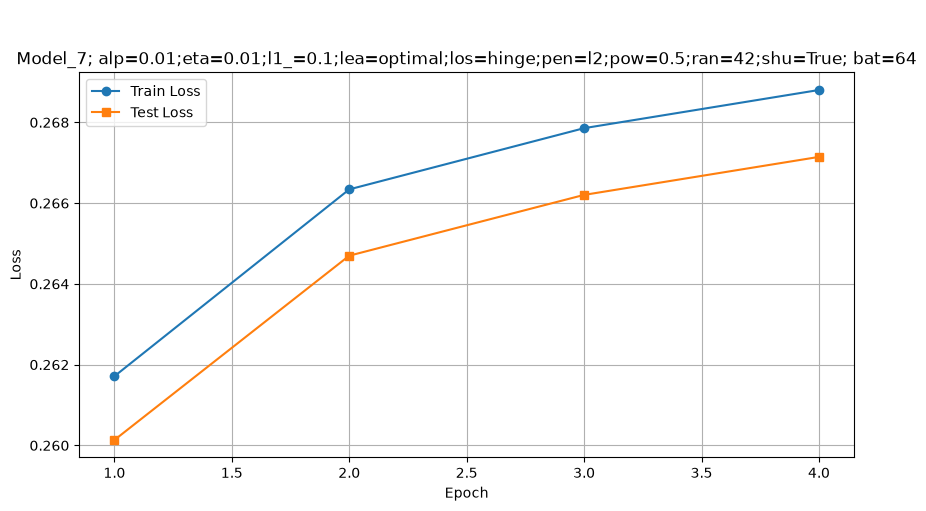

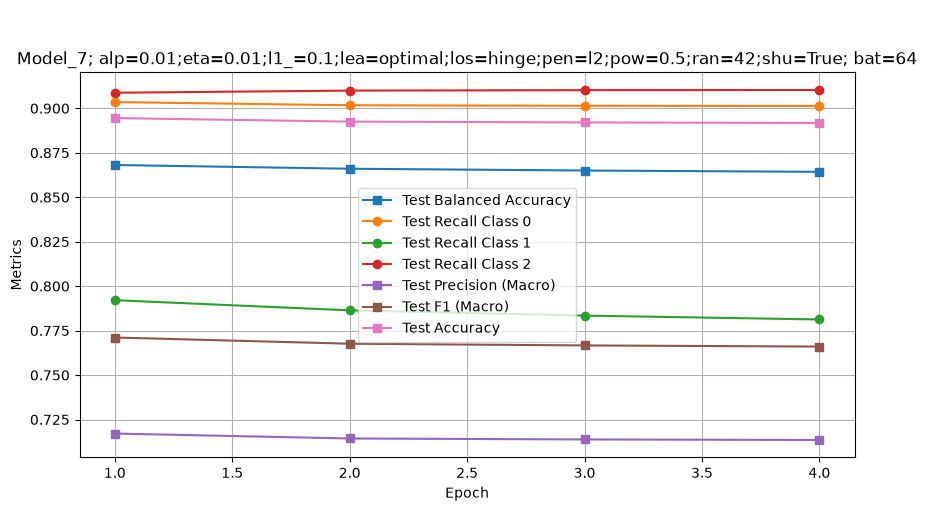

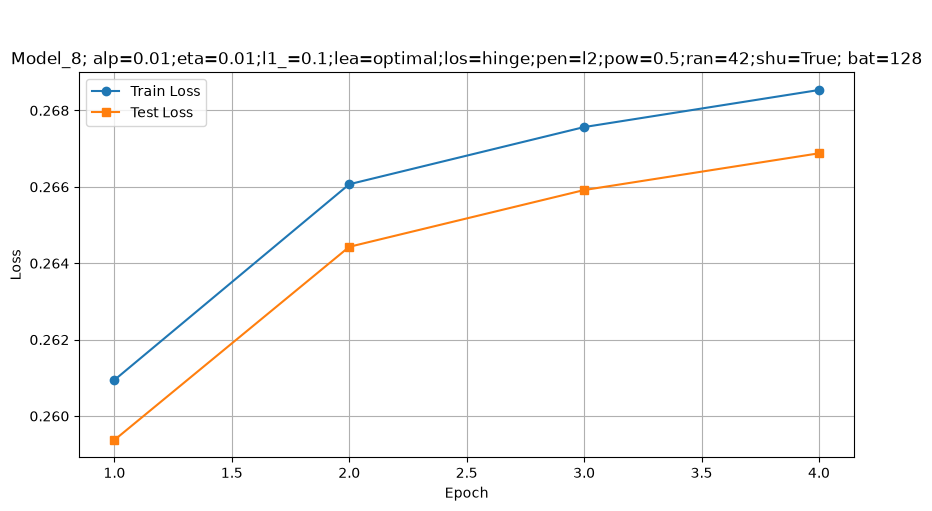

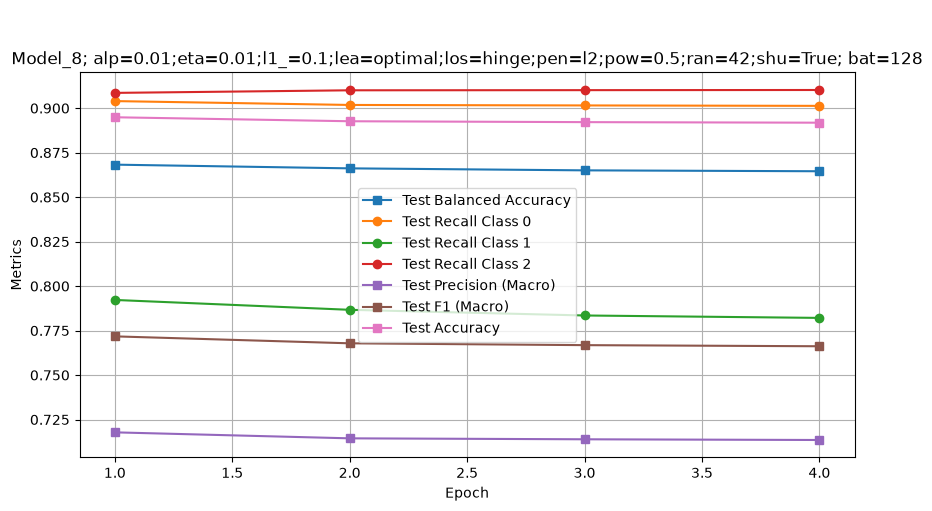

KeyboardInterrupt: 

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    recall_score, precision_score, f1_score, 
    accuracy_score, balanced_accuracy_score, 
    log_loss, hinge_loss
)

# Настройка логирования обучения
log_filename = os.path.join(
    log_dir, 
    f'training_log_{datetime.now().strftime("%Y%m%d_%H%M%S")}.log'
)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(message)s',
    handlers=[
        logging.FileHandler(log_filename)
    ],
    force=True 
)

param_grid = {
    "loss": ["log_loss", "hinge"], 
    "penalty": ['l2', "l1"],
    "alpha": [1e-2, 1e-3, 1e-4], 
    "l1_ratio": [0.1, 0.4, 0.7], 
    "shuffle": [True], 
    "random_state": [RS], 
    "learning_rate": ['optimal', "invscaling", "adaptive"], 
    "eta0": [0.01], 
    "power_t": [0.5]
}

batch_sizes = [32, 64, 128]
max_iters = 10
tol = 1e-4
n_iters_no_change = 3
classes = np.unique(y_train)  # Массив уникальных классов, например [0, 1, 2]
n_classes = len(classes)

model_num = 0

# Инициализируем ALL_METRICS с учетом Recall для каждого класса
ALL_METRICS = {
    "bal_acc": [], 
    "precision": [], 
    "f1": [], 
    "accuracy": []
}
for c in classes:
    ALL_METRICS[f"recall_cls_{c}"] = []

for params in ParameterGrid(param_grid):
    for batch_size in batch_sizes:
        string_title = f"\n\nModel_{model_num}; " + ";".join([f"{k[:3]}={v}" for k, v in params.items()]) + f"; bat={batch_size}"

        logging.info(f"")
        logging.info(f"")
        logging.info(f"")
        logging.info("===============parameters===============")
        logging.info(f"batch size: {batch_size}")
        for key, val in params.items():
            logging.info(f"{key}: {val}")
        logging.info("========================================")

        sgd = SGDClassifier(**params, class_weight=dict(zip(np.unique(y_train), y_train.shape[0] / (3 * np.bincount(y_train)))))

        loss_train_hist = []
        loss_test_hist = []
        bal_acc_test_hist = []
        # Список списков для истории Recall каждого класса: [[cls0_hist], [cls1_hist], [cls2_hist]]
        recall_test_hist = [[] for _ in range(n_classes)]
        precision_test_hist = []
        f1_test_hist = []
        accuracy_test_hist = []

        # Инициализируем BEST_METRICS для каждого класса
        BEST_METRICS = {
            "bal_acc": [-1.0, 0], 
            "precision": [-1.0, 0], 
            "f1": [-1.0, 0], 
            "accuracy": [-1.0, 0]
        }
        for c in classes:
            BEST_METRICS[f"recall_cls_{c}"] = [-1.0, 0]

        local_count = 0 

        for epoch in range(max_iters):
            logging.info(f"\n--- EPOCH {epoch+1}/{max_iters} ---")
            
            # Побачевое обучение
            n_samples = X_train.shape[0]
            for ind in range(0, n_samples, batch_size):
                if hasattr(X_train, "iloc"):
                    X_batch = X_train.iloc[ind:ind+batch_size]
                    y_batch = y_train.iloc[ind:ind+batch_size]
                else:
                    X_batch = X_train[ind:ind+batch_size]
                    y_batch = y_train[ind:ind+batch_size]
                
                sgd.partial_fit(X_batch, y_batch, classes=classes)

            # Расчет Loss с учетом типа функции потерь
            if params["loss"] == "log_loss": 
                cur_loss_train = log_loss(y_train, sgd.predict_proba(X_train))
                cur_loss_test = log_loss(y_val_test, sgd.predict_proba(X_val_test))
            elif params["loss"] == "hinge":
                cur_loss_train = hinge_loss(y_train, sgd.decision_function(X_train))
                cur_loss_test = hinge_loss(y_val_test, sgd.decision_function(X_val_test))

            loss_train_hist.append(cur_loss_train)
            loss_test_hist.append(cur_loss_test)
            logging.info(f"loss_train: {cur_loss_train:.4f} | loss_test: {cur_loss_test:.4f}")

            # Предсказание и расчет метрик
            y_pred = sgd.predict(X_val_test)

            cur_bal_acc = balanced_accuracy_score(y_val_test, y_pred)
            
            # Расчет Recall отдельно для каждого класса
            cur_recalls = recall_score(y_val_test, y_pred, average=None, labels=classes, zero_division=0)
            
            cur_precision = precision_score(y_val_test, y_pred, average='macro', zero_division=0)
            cur_f1 = f1_score(y_val_test, y_pred, average='macro', zero_division=0)
            cur_acc = accuracy_score(y_val_test, y_pred)

            # Сохраняем значения в историю
            bal_acc_test_hist.append(cur_bal_acc)
            for idx in range(n_classes):
                recall_test_hist[idx].append(cur_recalls[idx])
            precision_test_hist.append(cur_precision)
            f1_test_hist.append(cur_f1)
            accuracy_test_hist.append(cur_acc)

            # Формируем словарь текущих метрик для вывода и поиска лучших
            epoch_metrics = {
                "bal_acc": cur_bal_acc,
                "precision": cur_precision,
                "f1": cur_f1,
                "accuracy": cur_acc
            }
            for idx, c in enumerate(classes):
                epoch_metrics[f"recall_cls_{c}"] = cur_recalls[idx]

            # Логирование и обновление лучших значений
            for met_name, val in epoch_metrics.items():
                logging.info(f"{met_name:<20} {val:.4f}")
                if val > BEST_METRICS[met_name][0]:
                    BEST_METRICS[met_name] = [val, epoch + 1]

            # Early Stopping
            if len(loss_test_hist) >= 2:
                if (loss_test_hist[-2] - loss_test_hist[-1]) < tol:
                    local_count += 1
                    if local_count == n_iters_no_change:
                        logging.warning(f"------------------------> Ранняя остановка для модели {model_num} на эпохе {epoch+1} <------------------------")
                        break
                else:
                    local_count = 0

        logging.info("="*60)
        for met_name, elem in BEST_METRICS.items():
            logging.info(f"{met_name:<20} max_val:{elem[0]:<10.4f} epoch:{elem[1]:<5}")
            ALL_METRICS[met_name].append([model_num, elem[0]])

        epochs_range = range(1, len(loss_train_hist) + 1)

        # График потерь
        plt.figure(figsize=(10, 5))
        plt.plot(epochs_range, loss_train_hist, label='Train Loss', marker='o')
        plt.plot(epochs_range, loss_test_hist, label='Test Loss', marker='s')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(string_title)
        plt.legend()
        plt.grid(True)
        plt.savefig(f"loss/model_{model_num}_{string_title}.png", dpi=300, bbox_inches='tight')
        plt.show()

        # График метрик
        plt.figure(figsize=(10, 5))
        plt.plot(epochs_range, bal_acc_test_hist, label='Test Balanced Accuracy', marker='s')
        
        # Отрисовка Recall для каждого класса отдельно
        for idx, c in enumerate(classes):
            plt.plot(epochs_range, recall_test_hist[idx], label=f'Test Recall Class {c}', marker='o')
            
        plt.plot(epochs_range, precision_test_hist, label='Test Precision (Macro)', marker='s')
        plt.plot(epochs_range, f1_test_hist, label='Test F1 (Macro)', marker='s')
        plt.plot(epochs_range, accuracy_test_hist, label='Test Accuracy', marker='s')
        
        plt.xlabel('Epoch')
        plt.ylabel('Metrics')
        plt.title(string_title)
        plt.legend()
        plt.grid(True)
        plt.savefig(f"metrics/model_{model_num}_{string_title}.png", dpi=300, bbox_inches='tight')
        plt.show()

        model_num += 1

create_table(ALL_METRICS)

In [ ]:
print((y_train == 0).sum(), (y_train == 1).sum(), (y_train == 2).sum())
print((y_val_test == 0).sum(), (y_val_test == 1).sum(), (y_val_test == 2).sum())

405746 39539 27262
173892 16946 11683


: 

'123'

In [1]:
import numpy as np

arr_1 = np.array([1, 2, 3])

arr_2 = np.array([10, 4, 3])

result = arr_1 + arr_2

print(result)

[11  6  6]
